# Function Generation: Match Input/Output Angles

**Function generation** is one of the three classical mechanism synthesis problems.
The goal is to design a four-bar linkage where the input crank angle $\theta_2$
maps to a desired output rocker angle $\theta_4$ according to a specified
functional relationship.

This is based on **Freudenstein's equation** (1955), which relates the input/output
angles to the link length ratios:

$$R_1 \cos\theta_4 - R_2 \cos\theta_2 + R_3 - \cos(\theta_2 - \theta_4) = 0$$

where $R_1 = d/a$, $R_2 = d/c$, and $R_3 = (a^2 - b^2 + c^2 + d^2)/(2ac)$,
with $a$, $b$, $c$, $d$ being the crank, coupler, rocker, and ground link lengths.

**What you'll learn:**
- How to define angle pairs for function generation
- Using `function_generation()` to synthesize a four-bar linkage
- Grashof classification of the resulting mechanism
- Converting synthesis results to a simulatable linkage
- Validating that the synthesized linkage matches the desired angle relationship
- Handling overdetermined (least-squares) problems with more than 3 angle pairs

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np

from pylinkage.synthesis import (
    function_generation,
    solution_to_linkage,
    verify_function_generation,
)
from pylinkage.synthesis.utils import grashof_check

## 1. Define Precision Angle Pairs

We want the rocker angle $\theta_4$ to respond nonlinearly to the crank angle $\theta_2$.
Specifically, the output leads the input at small angles and converges to match it
at larger angles — a decelerating transfer function.

With exactly 3 angle pairs, Freudenstein's equation gives an exact (unique) solution
for the link length ratios $R_1$, $R_2$, $R_3$.

In [2]:
# Define 3 precision angle pairs: (input_angle, output_angle)
# Desired relationship: output leads input initially, then converges
angle_pairs_3 = [
    (math.radians(30),  math.radians(75)),   # 30 deg -> 75 deg (output leads by 45 deg)
    (math.radians(75),  math.radians(90)),   # 75 deg -> 90 deg (output leads by 15 deg)
    (math.radians(135), math.radians(135)),  # 135 deg -> 135 deg (output equals input)
]

print("Precision angle pairs (degrees):")
for i, (t2, t4) in enumerate(angle_pairs_3):
    print(
            f"  Pair {i+1}: input = {math.degrees(t2):6.1f} deg,  "
            f"output = {math.degrees(t4):6.1f} deg"
        )

Precision angle pairs (degrees):
  Pair 1: input =   30.0 deg,  output =   75.0 deg
  Pair 2: input =   75.0 deg,  output =   90.0 deg
  Pair 3: input =  135.0 deg,  output =  135.0 deg


## 2. Run Function Generation Synthesis

Call `function_generation()` with our angle pairs. We set `ground_length=1.0`
as a scaling factor and `require_grashof=False` to see all solutions
(Grashof and non-Grashof alike).

In [3]:
result = function_generation(
    angle_pairs=angle_pairs_3,
    ground_length=1.0,
    require_grashof=False,
)

print(f"Number of raw solutions: {len(result.raw_solutions)}")
print(f"Number of linkage solutions: {len(result.solutions)}")

if result.warnings:
    print("\nWarnings:")
    for w in result.warnings:
        print(f"  - {w}")

Number of raw solutions: 1
Number of linkage solutions: 1


## 3. Examine Link Lengths and Grashof Classification

The Grashof criterion tells us whether any link can make a full rotation.
For function generation, a **crank-rocker** type is ideal: the crank
rotates fully while the rocker oscillates.

In [4]:
for i, sol in enumerate(result.raw_solutions):
    gt = grashof_check(
        sol.crank_length,
        sol.coupler_length,
        sol.rocker_length,
        sol.ground_length,
    )
    print(f"Solution {i}:")
    print(f"  Crank (a)   = {sol.crank_length:.4f}")
    print(f"  Coupler (b) = {sol.coupler_length:.4f}")
    print(f"  Rocker (c)  = {sol.rocker_length:.4f}")
    print(f"  Ground (d)  = {sol.ground_length:.4f}")
    print(f"  Grashof type: {gt.name}")
    print()

Solution 0:
  Crank (a)   = 0.7822
  Coupler (b) = 0.8434
  Rocker (c)  = 1.0297
  Ground (d)  = 1.0000
  Grashof type: GRASHOF_CRANK_ROCKER



## 4. Convert to Linkage and Simulate

Convert the best raw solution into a `Linkage` object that we can
simulate. The linkage has joints A (ground), D (ground), B (crank output),
and C (revolute connecting coupler to rocker).

In [5]:
sol = result.raw_solutions[0]
linkage = solution_to_linkage(sol, name="func-gen", iterations=200)

print(f"Joints: {[j.name for j in linkage.joints]}")
print(f"Solve order: {[j.name for j in linkage._solve_order]}")

Joints: ['A', 'D', 'B', 'C']
Solve order: ['B', 'C']


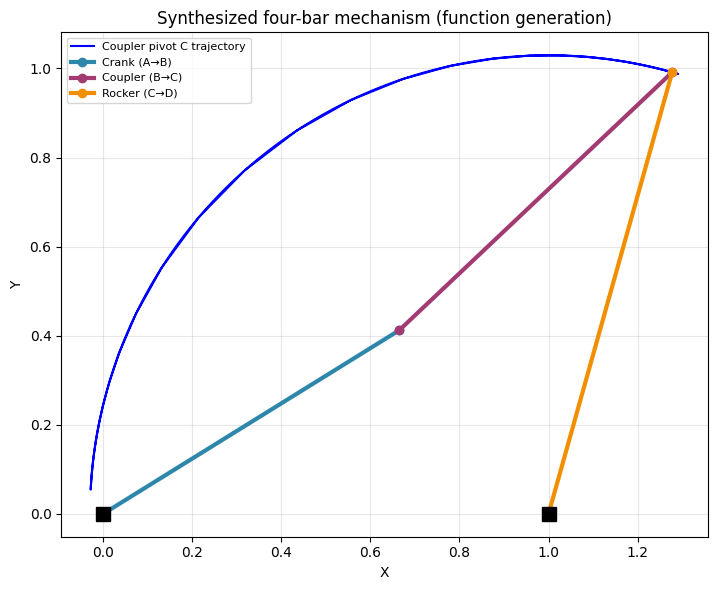

In [6]:
# Simulate one full crank rotation
loci = list(linkage.step(iterations=200))

# Extract the coupler pivot C trajectory (index 3: A=0, D=1, B=2, C=3)
coupler_path = [
    (pos[3][0], pos[3][1])
    for pos in loci
    if pos[3][0] is not None
]

cx, cy = zip(*coupler_path, strict=False)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(cx, cy, "b-", linewidth=1.5, label="Coupler pivot C trajectory")

# Draw the mechanism at its initial position (frame 0)
pos = loci[0]
link_pairs = [(0, 2), (2, 3), (3, 1)]  # A-B, B-C, C-D
link_labels = ['Crank (A→B)', 'Coupler (B→C)', 'Rocker (C→D)']
link_colors = ['#2E86AB', '#A23B72', '#F18F01']
for (i, j), color, label in zip(link_pairs, link_colors, link_labels, strict=False):
    ax.plot([pos[i][0], pos[j][0]], [pos[i][1], pos[j][1]],
            '-o', color=color, linewidth=3, markersize=6, label=label)

# Mark ground pivots
ax.plot(sol.ground_pivot_a[0], sol.ground_pivot_a[1], "ks", markersize=10, zorder=5)
ax.plot(sol.ground_pivot_d[0], sol.ground_pivot_d[1], "ks", markersize=10, zorder=5)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Synthesized four-bar mechanism (function generation)")
ax.set_aspect("equal")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Validation: Desired vs. Actual Rocker Angles

The key test for function generation: for each precision angle pair,
set the crank to the input angle, determine the rocker angle geometrically,
and compare to the desired output angle.

We use `verify_function_generation()` which handles the circle-circle
intersection and branch selection internally.

In [7]:
all_ok, errors = verify_function_generation(linkage, angle_pairs_3, tolerance=0.05)

print(f"All within tolerance: {all_ok}\n")
print(f"{'Pair':>6}  {'Input (deg)':>12}  {'Desired (deg)':>14}  {'Error (deg)':>12}")
print("-" * 50)
for i, ((t2, t4), err) in enumerate(zip(angle_pairs_3, errors, strict=False)):
    print(
        f"{i+1:>6}  {math.degrees(t2):>12.1f}  "
f"{math.degrees(t4):>14.1f}  {math.degrees(err):>12.4f}"
    )

All within tolerance: True

  Pair   Input (deg)   Desired (deg)   Error (deg)
--------------------------------------------------
     1          30.0            75.0        0.0000
     2          75.0            90.0        0.0000
     3         135.0           135.0        0.0000


Now let's also compute and plot the actual rocker angle across a range
of crank angles to see the full transfer function of the synthesized linkage.
A linear relationship ($\theta_4 = \theta_2$) is shown for reference.

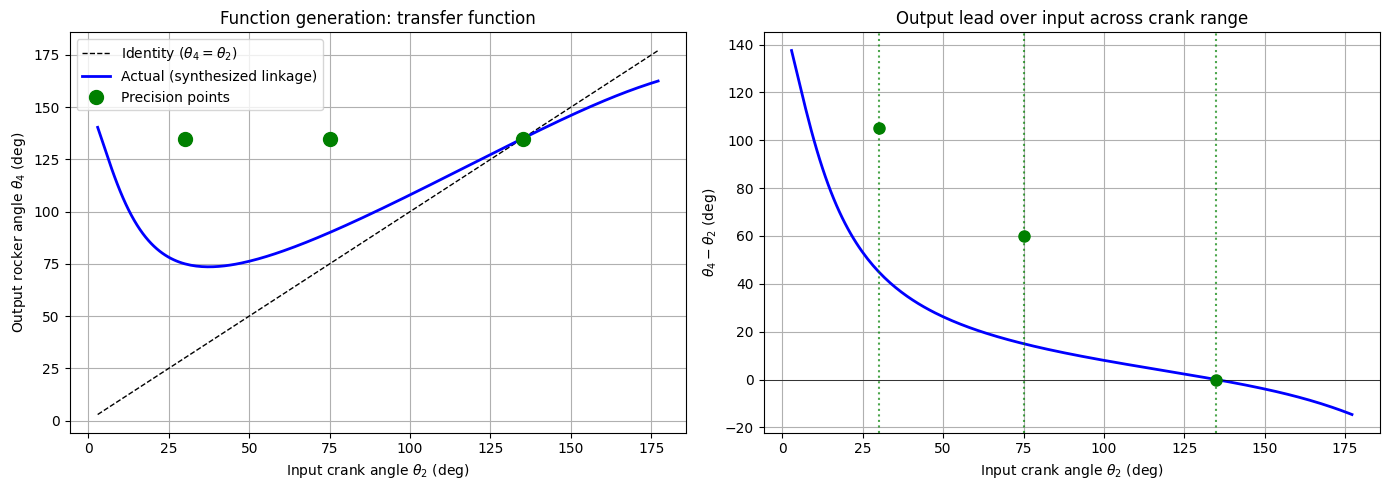

In [8]:
from pylinkage.geometry.secants import circle_intersect

# Extract link parameters from the solution
A = sol.ground_pivot_a
D = sol.ground_pivot_d
a = sol.crank_length
b = sol.coupler_length
c = sol.rocker_length

# Sweep crank angle and compute actual rocker angle
theta2_range = np.linspace(0.05, math.pi - 0.05, 200)
actual_theta4 = []
valid_theta2 = []

for theta2 in theta2_range:
    # Crank tip position
    Bx = A[0] + a * math.cos(theta2)
    By = A[1] + a * math.sin(theta2)

    # Circle-circle intersection: C is at distance b from B and c from D
    n_int, x1, y1, x2, y2 = circle_intersect(Bx, By, b, D[0], D[1], c)
    if n_int == 0:
        continue

    # Choose the solution with positive y (upper branch)
    t4_1 = math.atan2(y1 - D[1], x1 - D[0])
    if n_int == 2:
        t4_2 = math.atan2(y2 - D[1], x2 - D[0])
        # Pick the branch with positive angle (upper configuration)
        if t4_2 > t4_1:
            t4_1 = t4_2

    actual_theta4.append(t4_1)
    valid_theta2.append(theta2)

valid_theta2 = np.array(valid_theta2)
actual_theta4 = np.array(actual_theta4)

# Plot actual transfer function vs. identity (theta4 = theta2)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: angle relationship
ax1.plot(
    np.degrees(valid_theta2), np.degrees(valid_theta2),
    "k--", linewidth=1, label=r"Identity ($\theta_4 = \theta_2$)"
)
ax1.plot(
    np.degrees(valid_theta2), np.degrees(actual_theta4),
    "b-", linewidth=2, label="Actual (synthesized linkage)"
)
# Mark precision points
for t2, _t4 in angle_pairs_3:
    ax1.plot(math.degrees(t2), math.degrees(t4), "go", markersize=10, zorder=5)
ax1.plot([], [], "go", markersize=10, label="Precision points")
ax1.set_xlabel("Input crank angle $\\theta_2$ (deg)")
ax1.set_ylabel("Output rocker angle $\\theta_4$ (deg)")
ax1.set_title("Function generation: transfer function")
ax1.legend()
ax1.grid(True)

# Right: deviation from identity
deviation_deg = np.degrees(actual_theta4 - valid_theta2)
ax2.plot(np.degrees(valid_theta2), deviation_deg, "b-", linewidth=2)
ax2.axhline(y=0, color="k", linestyle="-", linewidth=0.5)
for t2, _t4 in angle_pairs_3:
    ax2.axvline(x=math.degrees(t2), color="g", linestyle=":", alpha=0.7)
    ax2.plot(math.degrees(t2), math.degrees(t4 - t2), "go", markersize=8, zorder=5)
ax2.set_xlabel("Input crank angle $\\theta_2$ (deg)")
ax2.set_ylabel("$\\theta_4 - \\theta_2$ (deg)")
ax2.set_title("Output lead over input across crank range")
ax2.grid(True)

plt.tight_layout()
plt.show()

The precision points (green dots) lie exactly on the synthesized curve.
Between precision points, the actual transfer function deviates — this
**structural error** is inherent to finite-precision synthesis.

The right plot shows that the output leads the input significantly at low
crank angles and converges to zero lead around 135 deg, exactly as specified.

## 6. Overdetermined Case: 5 Angle Pairs (Least-Squares)

With more than 3 angle pairs, the system is overdetermined. The synthesis
uses least-squares to find the best-fit Freudenstein coefficients.
The result is approximate at all points but may give a better overall
fit across the range.

In [9]:
# Define 5 precision angle pairs for the same general relationship
# (output leads input at small angles, converges at large angles)
angle_pairs_5 = [
    (math.radians(30),  math.radians(75)),   # (30 deg, 75 deg)
    (math.radians(60),  math.radians(85)),   # (60 deg, 85 deg)
    (math.radians(75),  math.radians(90)),   # (75 deg, 90 deg)
    (math.radians(110), math.radians(118)),  # (110 deg, 118 deg)
    (math.radians(135), math.radians(135)),  # (135 deg, 135 deg)
]

print("Overdetermined precision angle pairs (degrees):")
for i, (t2, t4) in enumerate(angle_pairs_5):
    print(
            f"  Pair {i+1}: input = {math.degrees(t2):6.1f} deg,  "
            f"output = {math.degrees(t4):6.1f} deg"
        )

Overdetermined precision angle pairs (degrees):
  Pair 1: input =   30.0 deg,  output =   75.0 deg
  Pair 2: input =   60.0 deg,  output =   85.0 deg
  Pair 3: input =   75.0 deg,  output =   90.0 deg
  Pair 4: input =  110.0 deg,  output =  118.0 deg
  Pair 5: input =  135.0 deg,  output =  135.0 deg


In [10]:
result_5 = function_generation(
    angle_pairs=angle_pairs_5,
    ground_length=1.0,
    require_grashof=False,
)

print(f"Number of solutions: {len(result_5.raw_solutions)}")

if result_5.warnings:
    print("\nWarnings:")
    for w in result_5.warnings:
        print(f"  - {w}")

if result_5.raw_solutions:
    sol_5 = result_5.raw_solutions[0]
    gt_5 = grashof_check(
        sol_5.crank_length,
        sol_5.coupler_length,
        sol_5.rocker_length,
        sol_5.ground_length,
    )
    print("\nLink lengths:")
    print(f"  Crank (a)   = {sol_5.crank_length:.4f}")
    print(f"  Coupler (b) = {sol_5.coupler_length:.4f}")
    print(f"  Rocker (c)  = {sol_5.rocker_length:.4f}")
    print(f"  Ground (d)  = {sol_5.ground_length:.4f}")
    print(f"  Grashof type: {gt_5.name}")

Number of solutions: 1

Warnings:
  - Least squares fit residual = 0.0590. The specified angles may not be exactly achievable.

Link lengths:
  Crank (a)   = 0.7796
  Coupler (b) = 0.8242
  Rocker (c)  = 1.0305
  Ground (d)  = 1.0000
  Grashof type: GRASHOF_CRANK_ROCKER


In [11]:
# Convert and validate the 5-point solution
if result_5.raw_solutions:
    linkage_5 = solution_to_linkage(sol_5, name="func-gen-5pt", iterations=200)

    all_ok_5, errors_5 = verify_function_generation(
        linkage_5, angle_pairs_5, tolerance=0.1
    )

    print(f"All within tolerance (0.1 rad): {all_ok_5}\n")
    print(f"{'Pair':>6}  {'Input (deg)':>12}  {'Desired (deg)':>14}  {'Error (deg)':>12}")
    print("-" * 50)
    for i, ((t2, t4), err) in enumerate(zip(angle_pairs_5, errors_5, strict=False)):
        print(
            f"{i+1:>6}  {math.degrees(t2):>12.1f}  "
f"{math.degrees(t4):>14.1f}  {math.degrees(err):>12.4f}"
        )

All within tolerance (0.1 rad): True

  Pair   Input (deg)   Desired (deg)   Error (deg)
--------------------------------------------------
     1          30.0            75.0        2.5407
     2          60.0            85.0        2.6879
     3          75.0            90.0        1.2242
     4         110.0           118.0        1.2368
     5         135.0           135.0        1.1571


## 7. Compare 3-Point vs. 5-Point Approximation Quality

Let's overlay the structural error curves from both solutions to see
how the overdetermined least-squares fit compares to the exact 3-point
synthesis.

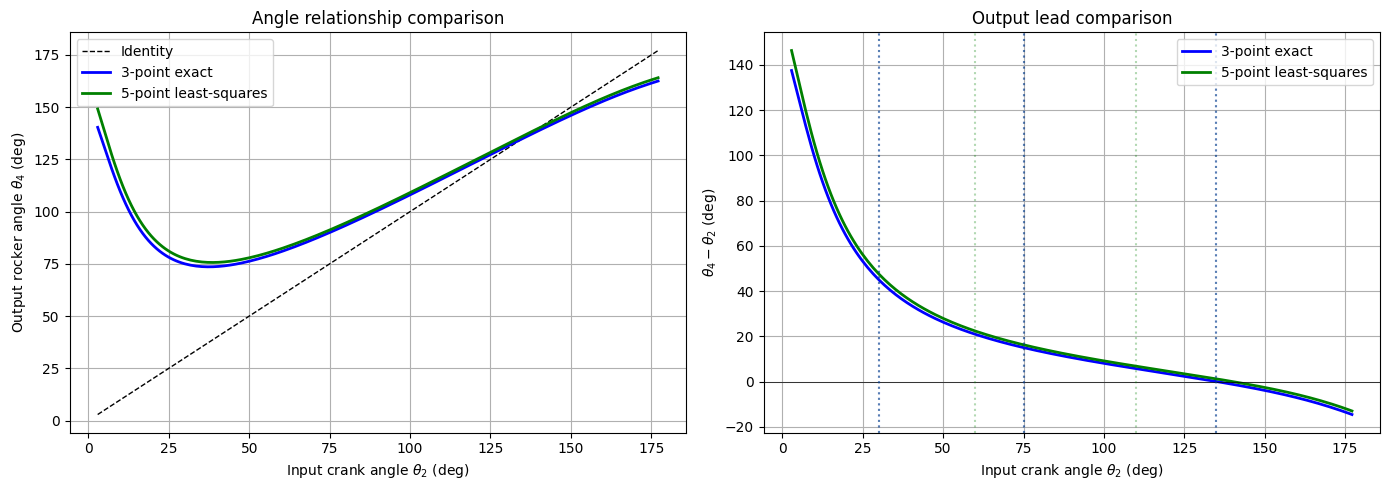

In [12]:
def compute_rocker_angles(solution, theta2_array):
    """Compute actual rocker angles for a range of crank angles."""
    A = solution.ground_pivot_a
    D = solution.ground_pivot_d
    a = solution.crank_length
    b = solution.coupler_length
    c = solution.rocker_length

    valid_t2 = []
    actual_t4 = []

    for theta2 in theta2_array:
        Bx = A[0] + a * math.cos(theta2)
        By = A[1] + a * math.sin(theta2)
        n_int, x1, y1, x2, y2 = circle_intersect(Bx, By, b, D[0], D[1], c)
        if n_int == 0:
            continue
        t4_1 = math.atan2(y1 - D[1], x1 - D[0])
        if n_int == 2:
            t4_2 = math.atan2(y2 - D[1], x2 - D[0])
            if t4_2 > t4_1:
                t4_1 = t4_2
        actual_t4.append(t4_1)
        valid_t2.append(theta2)

    return np.array(valid_t2), np.array(actual_t4)


theta2_sweep = np.linspace(0.05, math.pi - 0.05, 200)

# 3-point solution
t2_3, t4_3 = compute_rocker_angles(result.raw_solutions[0], theta2_sweep)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: both angle relationships
ax1.plot(np.degrees(t2_3), np.degrees(t2_3), "k--", linewidth=1, label="Identity")
ax1.plot(np.degrees(t2_3), np.degrees(t4_3), "b-", linewidth=2, label="3-point exact")

if result_5.raw_solutions:
    t2_5, t4_5 = compute_rocker_angles(result_5.raw_solutions[0], theta2_sweep)
    ax1.plot(np.degrees(t2_5), np.degrees(t4_5), "g-", linewidth=2, label="5-point least-squares")

ax1.set_xlabel("Input crank angle $\\theta_2$ (deg)")
ax1.set_ylabel("Output rocker angle $\\theta_4$ (deg)")
ax1.set_title("Angle relationship comparison")
ax1.legend()
ax1.grid(True)

# Right: deviation from identity (output lead)
lead_3 = np.degrees(t4_3 - t2_3)
ax2.plot(np.degrees(t2_3), lead_3, "b-", linewidth=2, label="3-point exact")
if result_5.raw_solutions:
    lead_5 = np.degrees(t4_5 - t2_5)
    ax2.plot(np.degrees(t2_5), lead_5, "g-", linewidth=2, label="5-point least-squares")
ax2.axhline(y=0, color="k", linestyle="-", linewidth=0.5)

# Mark precision points
for t2, _t4 in angle_pairs_3:
    ax2.axvline(x=math.degrees(t2), color="b", linestyle=":", alpha=0.5)
for t2, _t4 in angle_pairs_5:
    ax2.axvline(x=math.degrees(t2), color="g", linestyle=":", alpha=0.3)

ax2.set_xlabel("Input crank angle $\\theta_2$ (deg)")
ax2.set_ylabel("$\\theta_4 - \\theta_2$ (deg)")
ax2.set_title("Output lead comparison")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 8. Simulate the 5-Point Linkage

Let's also visualize the coupler trajectory of the 5-point solution
and draw a few ghosted frames of the mechanism.

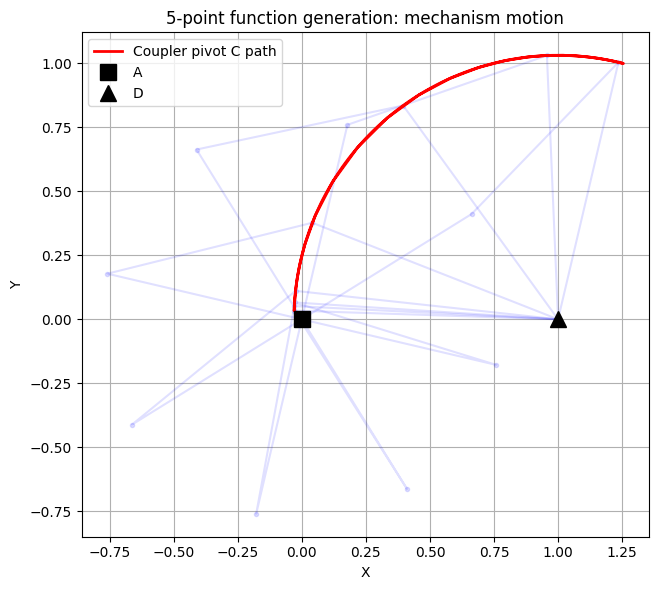

In [13]:
if result_5.raw_solutions:
    linkage_5.rebuild()
    loci_5 = list(linkage_5.step(iterations=200))

    fig, ax = plt.subplots(figsize=(8, 6))

    # Draw ghosted mechanism frames
    for frame_idx in range(0, len(loci_5), 25):
        pos = loci_5[frame_idx]
        # Links: A-B, B-C, C-D (indices: A=0, D=1, B=2, C=3)
        joints_x = [pos[0][0], pos[2][0], pos[3][0], pos[1][0]]
        joints_y = [pos[0][1], pos[2][1], pos[3][1], pos[1][1]]
        if all(x is not None for x in joints_x):
            ax.plot(joints_x, joints_y, "b-o", alpha=0.12, markersize=3)

    # Coupler pivot trajectory
    c_path = [(pos[3][0], pos[3][1]) for pos in loci_5 if pos[3][0] is not None]
    if c_path:
        px, py = zip(*c_path, strict=False)
        ax.plot(px, py, "r-", linewidth=2, label="Coupler pivot C path")

    # Ground pivots
    ax.plot(sol_5.ground_pivot_a[0], sol_5.ground_pivot_a[1], "ks", markersize=12, label="A")
    ax.plot(sol_5.ground_pivot_d[0], sol_5.ground_pivot_d[1], "k^", markersize=12, label="D")

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title("5-point function generation: mechanism motion")
    ax.set_aspect("equal")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

## Summary

In this notebook we:

1. **Defined angle pairs** specifying a desired nonlinear input/output relationship (output leads input at small angles, converges at large angles)
2. **Synthesized a four-bar linkage** using `function_generation()` based on Freudenstein's equation
3. **Classified the solution** using the Grashof criterion
4. **Converted to a linkage** with `solution_to_linkage()` and simulated the coupler trajectory
5. **Validated** that the synthesized linkage exactly matches the desired angles at precision points using `verify_function_generation()`
6. **Compared exact vs. least-squares** synthesis: 3 angle pairs give zero error at precision points but may deviate between them; 5 angle pairs give a least-squares fit that spreads the error more evenly

**Key takeaways:**
- With 3 precision positions, Freudenstein's equation gives a unique exact solution
- With more positions, least-squares minimizes the overall fitting error
- The structural error (deviation between precision points) is inherent to finite-precision synthesis
- The Grashof criterion is essential for ensuring the mechanism can operate continuously

**Next steps:** Try different angle relationships (e.g., larger or smaller angular ranges),
explore `path_generation()` in notebook 01, or apply optimization (notebook 02)
to further refine the mechanism.